# Matrix Completion with the Nuclear Norm

Recover a low-rank matrix from a subset of its entries. Singular-value thresholding and Douglas–Rachford splitting provide a concrete way to combine a rank surrogate with exact agreement on observed values.


## Run this tour

Run the cells in order with a Python 3 kernel. The first cell locates the companion data and toolbox and installs missing dependencies when needed. All worked examples include their implementation directly in this notebook. Random seeds make comparisons reproducible; you can change them to explore other samples.


In [1]:
# Locate the companion toolbox locally, or fetch it for a standalone/Colab copy.
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

working = Path.cwd()
candidates = [working, working / "python", working.parent / "python"]
python_dir = next((p for p in candidates if (p / "nt_toolbox").is_dir()), None)
if python_dir is None:
    checkout = working / "numerical-tours-support"
    if not checkout.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "master",
                "https://github.com/gpeyre/numerical-tours.git",
                str(checkout),
            ],
            check=True,
        )
    python_dir = checkout / "python"
os.chdir(python_dir)
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))
requirements = python_dir / "requirements.txt"
if any(
    importlib.util.find_spec(name) is None
    for name in [
        "numpy",
        "scipy",
        "matplotlib",
        "skimage",
        "sklearn",
        "pywt",
        "ipywidgets",
        "cvxpy",
        "skfmm",
        "autograd",
        "progressbar",
        "celer",
    ]
):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(requirements)], check=True
    )

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "figure.dpi": 100,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "image.cmap": "gray",
    }
)
%matplotlib inline

**Matrix completion using trace norm regularization**

This shows the use of Douglas-Rachford's algorithm to perform matrix completion with trace norm (nuclear norm) regularization.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

We consider $n \times n$ matrices.


In [3]:
n = 100

Generate a rank $r$ random matrix.


In [4]:
r = 10
x0 = np.dot(np.random.randn(n, r), np.random.randn(r, n))

Display the singular values.


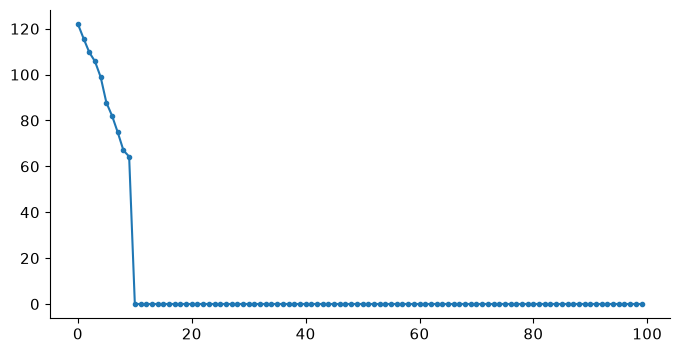

In [5]:
plt.plot(np.linalg.svd(x0)[1], ".-")

Random selection of $p$ indices.


In [6]:
def indices(n, p):
    return np.random.permutation(n**2)[0:p]

Associated forward (measurement) operator $\Phi$ and its adjoint $\Phi^\top$.


In [7]:
def phi(x, I):
    return x.flatten()[I]


def phi_adj(y, I):
    x = np.zeros(n**2)
    x[I] = y
    return x.reshape((n, n))


def dotp(x, y):
    return np.sum(x.flatten() * y.flatten())

Check adjointness of $\Phi$ and $\Phi^\top$.


In [8]:
p = 12
x = np.random.randn(n, n)
y = np.random.randn(p)
I = indices(n, p)
# must be 0
print(dotp(y, phi(x, I)) - dotp(phi_adj(y, I), x))

0.0


Define the proximal operator of $F(x) = \iota_{\Phi \cdot = y}(x)$ (ie the ortho-projector).


In [9]:
def prox_F(x, y, I):
    return x + phi_adj(y - phi(x, I), I)

Check that prox$_F \circ$ prox$_F$ = prox$_F$ (since it is a projector).


In [10]:
x1 = prox_F(x, y, I)
print(np.linalg.norm(x1 - prox_F(x1, y, I)))

1.5700924586837752e-16


Compute the proximal operator of $G(x):=\|x\|_*$ the nuclear norm, which is the soft-thesholding of the singular values.


In [11]:
def soft_thresholding(x, u):
    return np.minimum(x + u, np.maximum(0, x - u))

Displays the soft thresholding.


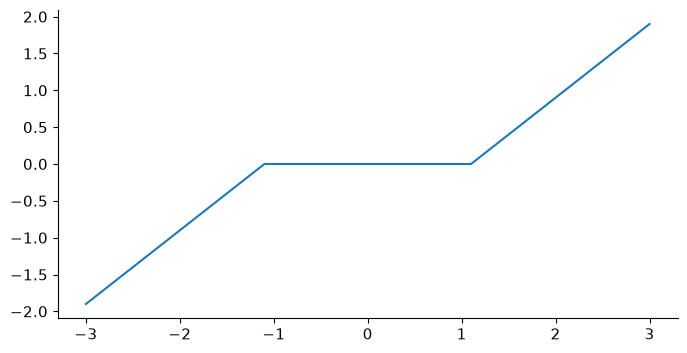

In [12]:
t = np.linspace(-3, 3, 1000)
plt.plot(t, soft_thresholding(t, 1.1));

In [13]:
def prox_G(x, gamma):
    u, s, vh = np.linalg.svd(x)
    soft_s = soft_thresholding(s, gamma)
    return (u * soft_s) @ vh

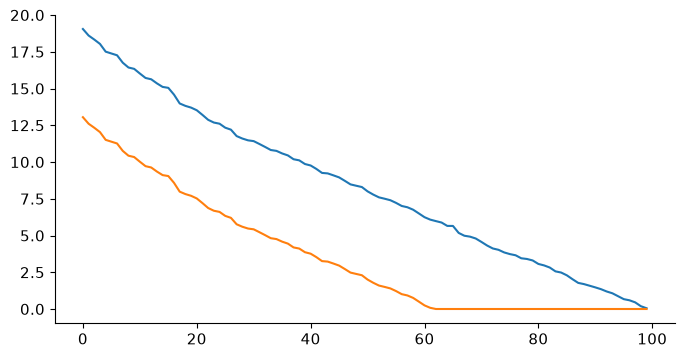

In [14]:
_, a, _ = np.linalg.svd(x)
_, b, _ = np.linalg.svd(prox_G(x, 6))
plt.plot(a)
plt.plot(b);

Compute the symmetrized proximal operator (rprox).


In [15]:
def rprox_F(x, gamma, y, I):
    return 2 * prox_F(x, y, I) - x


def rprox_G(x, gamma):
    return 2 * prox_G(x, gamma) - x

In [16]:
def n_norm(x):
    return np.linalg.norm(x, "nuc")

Douglas-Rachford's algorithm.


In [17]:
def DR(y, mu, gamma, n_iter, I):
    x_t = np.zeros((n, n))
    x_list = []
    x_t_list = []
    nucl_norm = []
    for i in range(n_iter):
        x_t_list.append(x_t.copy())
        x_t = (1 - mu / 2) * x_t + mu / 2 * rprox_G(rprox_F(x_t, gamma, y, I), gamma)
        x = prox_F(x_t, y, I)
        x_list.append(x.copy())
        nucl_norm.append(n_norm(x))
    return x, nucl_norm

Test the DR algorithm.


In [18]:
mu = 1
gamma = 1
p = int(0.5 * n * n)
I = indices(n, p)
x, nucl_norm = DR(phi(x0, I), mu, gamma, 500, I)

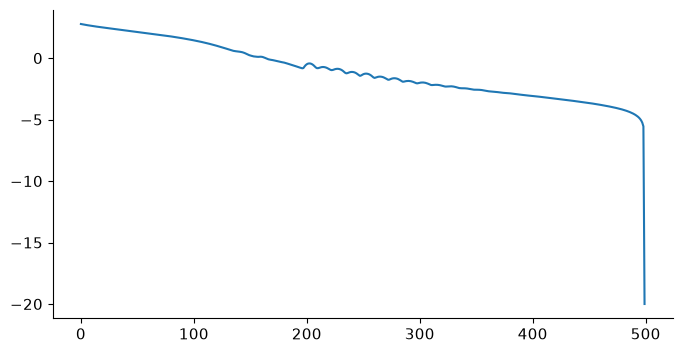

In [19]:
plt.plot(np.log10(nucl_norm - np.min(nucl_norm) + 1e-20))

Test with varying number $p$ of measurements.


In [20]:
r = 4
x0 = np.random.randn(n, r) @ np.random.randn(r, n)
# we varie p
n_test = 10  # number of tests
p_list = np.round(np.linspace(0.02, 0.5, n_test) * n**2)
err = []
n_iter = 500
import progressbar

for i in progressbar.progressbar(range(n_test)):
    p = int(p_list[i])
    I = indices(n, p)
    y = phi(x0, I)
    x, nucl_norm = DR(y, mu, gamma, n_iter, I)
    err.append(np.linalg.norm(x - x0))

  0% (0 of 10) |                          | Elapsed Time: 0:00:00 ETA: --:--:--

 10% (1 of 10) |##                         | Elapsed Time: 0:00:00 ETA: 0:00:05

 20% (2 of 10) |#####                      | Elapsed Time: 0:00:01 ETA: 0:00:04

 30% (3 of 10) |########                   | Elapsed Time: 0:00:01 ETA: 0:00:04

 40% (4 of 10) |##########                 | Elapsed Time: 0:00:02 ETA: 0:00:03

...

 60% (6 of 10) |################           | Elapsed Time: 0:00:03 ETA: 0:00:02

 70% (7 of 10) |##################         | Elapsed Time: 0:00:04 ETA: 0:00:02

 80% (8 of 10) |#####################      | Elapsed Time: 0:00:05 ETA: 0:00:01

 90% (9 of 10) |########################   | Elapsed Time: 0:00:06 ETA: 0:00:00

100% (10 of 10) |##########################| Elapsed Time: 0:00:06 ETA: 0:00:00

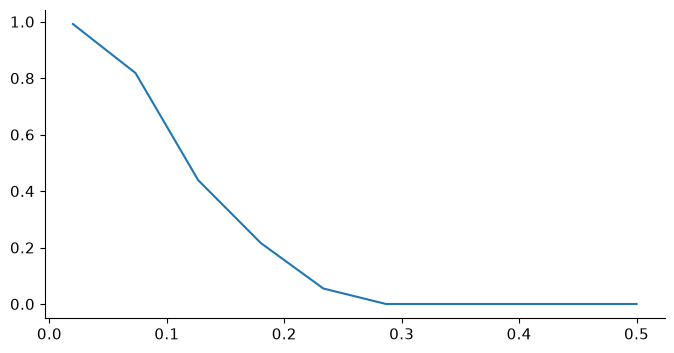

In [21]:
plt.plot(p_list / (n**2), err / np.linalg.norm(x0));

## References and further reading

- Emmanuel J. Candès and Benjamin Recht. [Exact Matrix Completion via Convex Optimization](https://arxiv.org/abs/0805.4471). 2009, Foundations of Computational Mathematics 9, 717–772. Low-rank recovery through nuclear-norm minimization.

- Jian-Feng Cai, Emmanuel J. Candès, and Zuowei Shen. [A Singular Value Thresholding Algorithm for Matrix Completion](https://arxiv.org/abs/0810.3286). 2010, SIAM Journal on Optimization 20(4), 1956–1982. The proximal operator of the nuclear norm.

- Neal Parikh and Stephen Boyd. [Proximal Algorithms](https://web.stanford.edu/~boyd/papers/prox_algs.html). 2014, Foundations and Trends in Optimization 1(3), 127–239. Proximity operators and splitting methods for nonsmooth objectives.

- Gilbert Strang. [Linear Algebra and Learning from Data](https://math.mit.edu/~gs/learningfromdata/). 2019, Wellesley-Cambridge Press. Matrix factorizations, least squares, and low-rank representations.

- Stephen Boyd and Lieven Vandenberghe. [Convex Optimization](https://web.stanford.edu/~boyd/cvxbook/). 2004, Cambridge University Press. Convexity, duality, optimality conditions, and interior-point methods.
